
# Reducción de dimensionalidad. PCA (Principal Component Analysis)

#### UT4. Aprendizaje no supervisado

#### MP. Sistemas de Aprendizaje Automático

#### Autores: Cristina Gómez Alonso, Carlos Tessier

---

Este contenido  está directamente relacionado con el:

RA4 – Aplica técnicas de aprendizaje no supervisado relacionándolas con los tipos de problemas que tratan de resolver.

En concreto, permite trabajar los siguientes criterios de evaluación:

* RA4.a) Caracterización de los problemas que resuelve el aprendizaje no supervisado, como la alta dimensionalidad.
* RA4.b) Explicación de técnicas no supervisadas como PCA.
* RA4.c) Aplicación práctica del algoritmo utilizando herramientas como Scikit-learn.
* RA4.d) Justificación del número de componentes seleccionados en función de la varianza explicada.

Además, contribuye al:

RA6 – Valoración de la calidad de los resultados obtenidos en la práctica.

---

## Resultados esperados en el alumnado

Al finalizar este bloque, el alumnado debe ser capaz de:

* Explicar qué problema resuelve PCA.
* Aplicarlo en un entorno práctico (por ejemplo, con Python y Scikit-learn).
* Interpretar el significado de la varianza explicada.
* Justificar el número de componentes seleccionados.
* Relacionar PCA con otras técnicas no supervisadas como el clustering.

---

## ¿Por qué necesitamos reducir dimensiones?

En muchos problemas reales trabajamos con un número elevado de variables o características. Por ejemplo, un dataset de clientes puede incluir edad, ingresos, gasto medio, frecuencia de compra y otras muchas variables. Una imagen puede estar formada por miles de píxeles y un texto puede convertirse en cientos de valores numéricos mediante técnicas de representación como los embeddings.

Cuando aumenta el número de variables:

* El entrenamiento de los modelos se vuelve más lento.
* Resulta más difícil encontrar patrones claros.
* Aumenta el riesgo de sobreajuste.
* La visualización de los datos se complica.

A este fenómeno se le denomina maldición de la dimensionalidad. A medida que crecen las dimensiones, los datos se dispersan más en el espacio y las distancias pierden significado, lo que puede afectar negativamente a algoritmos como el clustering.

---

## ¿Qué es la reducción de dimensionalidad?

La reducción de dimensionalidad consiste en disminuir el número de variables manteniendo la mayor cantidad posible de información relevante.

Puede compararse con resumir un libro extenso conservando las ideas principales. Se pierde parte del detalle, pero se mantiene la estructura esencial.

Es importante destacar que PCA no elimina variables originales, sino que crea nuevas variables que son combinaciones lineales de las anteriores.

<div style="text-align:center;">
    <img style="width:50%" src="img/img_1.png" />
</div>

<div style="text-align:center;">
    <img style="width:50%" src="img/img.png" />
</div>

---

## ¿Para qué se utiliza PCA en la práctica?

PCA se utiliza habitualmente para:

* Acelerar el entrenamiento de modelos.
* Mejorar el rendimiento de técnicas de clustering.
* Visualizar datos en dos o tres dimensiones.
* Reducir ruido en los datos.

En el contexto actual, PCA sigue siendo una técnica fundamental en aprendizaje automático clásico. En problemas más complejos, como visión artificial o procesamiento del lenguaje natural, se emplean también técnicas más avanzadas como t-SNE o UMAP para visualización, pero PCA continúa siendo una herramienta base en la formación técnica.

---

## Idea intuitiva de funcionamiento

Si trabajamos con dos variables, por ejemplo altura y peso, los datos pueden estar correlacionados. PCA busca la dirección en la que los datos presentan mayor variación y crea una nueva variable que resume esa información.

Estas nuevas variables se denominan componentes principales y se ordenan según la cantidad de varianza que explican:

* Componente principal 1: explica la mayor parte de la variabilidad.
* Componente principal 2: explica la siguiente mayor parte.

De este modo, podemos reducir el número de dimensiones conservando la mayor parte de la información relevante.

---






# 1. La maldición de la dimensionalidad

Estamos acostumbrados a pensar en 2 o 3 dimensiones: largo, ancho y alto. Sin embargo, en Machine Learning trabajamos con espacios que pueden tener decenas, cientos o miles de dimensiones. Cada variable del dataset añade una dimensión nueva.

Por ejemplo:

* 5 variables → espacio de 5 dimensiones
* 100 variables → espacio de 100 dimensiones
* 1000 variables → espacio de 1000 dimensiones

Aunque no podamos visualizar esos espacios, los algoritmos sí trabajan en ellos.

---

## ¿Qué ocurre cuando aumentan las dimensiones?

En espacios de alta dimensión suceden fenómenos poco intuitivos.

En dimensiones bajas (2D o 3D), los puntos suelen estar relativamente próximos entre sí. Sin embargo, cuando aumentan las dimensiones:

* Los puntos tienden a estar muy separados.
* Las distancias entre ellos se vuelven más similares.
* Resulta más difícil distinguir grupos naturales.

En otras palabras, “hay demasiado espacio”. Los datos se dispersan.

Esto implica que:

* Se necesitan muchos más datos para cubrir bien el espacio.
* Los algoritmos de clustering pueden funcionar peor.
* Las métricas de distancia pierden capacidad discriminatoria.

---

## Relación con el sobreajuste

Cuantas más dimensiones tenga un conjunto de datos:

* Más compleja puede volverse la frontera de decisión.
* Más fácil es que el modelo aprenda patrones específicos del entrenamiento.
* Mayor es el riesgo de sobreajuste.

Un modelo puede parecer muy preciso en entrenamiento, pero no generalizar bien a datos nuevos.

---



# 2. Principales aproximaciones a la reducción de dimensionalidad

---

## 2.1 Proyección

En muchos problemas reales, aunque trabajemos con muchas variables, los datos no se distribuyen de forma uniforme en todas las dimensiones. Es habitual que:

* Algunas características apenas varíen.
* Otras estén fuertemente correlacionadas.
* Parte de la información sea redundante.

Como consecuencia, las instancias de entrenamiento no ocupan todo el espacio de alta dimensión, sino que se concentran en un subespacio de menor dimensión dentro de ese espacio.

En la siguiente imagen se muestra un ejemplo conceptual. Aunque los datos están definidos en un espacio tridimensional, la mayoría de los puntos se sitúan cerca de un plano inclinado:

<div style="text-align:center;">
    <img style="width:50%" src="img/subspace_projection.png" />
</div>

Esto significa que, aunque formalmente trabajamos en 3 dimensiones, la estructura real de los datos es prácticamente bidimensional.

---

### Proyección sobre el subespacio

Si proyectamos perpendicularmente cada instancia sobre ese plano (el subespacio), obtenemos una representación con menos dimensiones que conserva la estructura principal de los datos.

El resultado sería algo similar a la siguiente imagen, donde los datos se representan en 2 dimensiones:

<div style="text-align:center;">
    <img style="width:50%" src="img/2d_projection.png" />
</div>

Ahora el problema se ha simplificado:

* Hemos pasado de 3 dimensiones a 2.
* Se mantiene la forma general de la distribución.
* Se reduce la complejidad del espacio.

---

### Limitación de la proyección directa

Sin embargo, la proyección no siempre es tan sencilla.

En muchos casos, el subespacio donde se concentran los datos no está alineado con los ejes originales (las variables tal como están definidas en el dataset). Puede estar girado o inclinado respecto a ellos.

Si eliminamos variables directamente sin tener en cuenta esa orientación, podríamos perder información importante.

Por ello, los métodos de reducción de dimensionalidad más avanzados, como PCA, no solo proyectan, sino que primero buscan la mejor orientación posible del subespacio antes de realizar la proyección.

---


## 2.2 Aprendizaje en variedades (Manifold Learning)

En el apartado anterior vimos que, aunque los datos puedan estar definidos en un espacio de muchas dimensiones, en realidad suelen concentrarse en una “superficie” de menor dimensión dentro de ese espacio.

A esa idea se le llama variedad (manifold).

Una variedad 2D es una superficie de dos dimensiones que puede estar doblada o curvada dentro de un espacio de mayor dimensión. Por ejemplo, una hoja de papel es bidimensional, aunque pueda estar arrugada o doblada en el espacio tridimensional.

De forma más general, muchos conjuntos de datos de alta dimensión no ocupan todo el espacio posible, sino que se concentran cerca de una estructura de menor dimensión.

---

### Hipótesis de la variedad

Muchos algoritmos de reducción de dimensionalidad se basan en la llamada hipótesis de la variedad.

Esta hipótesis afirma que:

La mayoría de los datos reales de alta dimensión se encuentran cerca de una estructura de menor dimensión.

Esta idea no es solo teórica, sino que se observa frecuentemente en la práctica.

---

### Ejemplo con imágenes 28x28

Si generamos todas las imágenes posibles en una cuadrícula de 28x28 píxeles, el número total de combinaciones posibles es enorme.

Sin embargo, solo una pequeña parte de esas combinaciones corresponde a imágenes que realmente se parecen a dígitos escritos a mano.



<div style="text-align:center;">
    <img style="width:50%" src="img/mnist-digit-7.png" alt="mnist-digit-7"  />
</div>

Esto significa que, aunque matemáticamente el espacio de todas las imágenes posibles es gigantesco, las imágenes reales de dígitos ocupan una región mucho más pequeña y estructurada dentro de ese espacio.

Esa región puede interpretarse como una variedad de menor dimensión.

Las restricciones físicas y estructurales del problema reducen enormemente los grados de libertad reales.

---

### Clasificación en un espacio curvado

La siguiente imagen muestra un ejemplo donde los datos están organizados en una estructura curva dentro de un espacio de mayor dimensión:

<div style="text-align:center;">
    <img style="width:50%" src="img/manifold_classification.png" alt="manifold_classification"/>
</div>

En algunos casos, si conseguimos “desenrollar” esa estructura y trabajar en la variedad subyacente, el problema de clasificación puede volverse más sencillo.

Sin embargo, esto no siempre ocurre.

Reducir la dimensionalidad puede acelerar el entrenamiento y simplificar la representación, pero no garantiza automáticamente una mejor solución. Todo depende del conjunto de datos y de la tarea concreta.

---





# 3. PCA: Principal Component Analysis

El análisis de componentes principales (PCA) es, con diferencia, el algoritmo de reducción de dimensionalidad más popular en aprendizaje automático.

PCA transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables no correlacionadas llamadas componentes principales, ordenadas según la cantidad de información que conservan.

PCA es un algoritmo sensible a la escala relativa de las variables originales. Si una variable tiene valores numéricamente más grandes que otra, influirá más en el cálculo de los componentes principales. Por ello, antes de aplicar PCA es habitual estandarizar los datos (media 0 y desviación típica 1).

El PCA fue inventado en 1901 por [Karl Pearson](https://en.wikipedia.org/wiki/Karl_Pearson) como un análogo del teorema del eje principal en mecánica. Más tarde fue desarrollado de forma independiente y nombrado por [Harold Hotelling](https://en.wikipedia.org/wiki/Harold_Hotelling) en la década de 1930. Aunque su origen es antiguo, sigue siendo una herramienta fundamental en ciencia de datos actual.

Para aplicar PCA, primero identificamos el hiperplano que mejor se ajusta a los datos y después proyectamos los datos sobre él.

Un hiperplano puede entenderse como:

* Una recta en 2 dimensiones.
* Un plano en 3 dimensiones.
* Una superficie equivalente en dimensiones superiores.

## 3.1 Preservación de la varianza

El objetivo de PCA es elegir el hiperplano que conserve la mayor varianza posible.

La varianza mide cuánto se dispersan los datos. Si proyectamos los puntos sobre distintas direcciones, algunas conservarán más información que otras.

En la siguiente imagen se muestran tres posibles ejes de proyección en un espacio 2D:

<div style="text-align:center;">
    <img style="width:66%" src="img/2D_variance_projection.png" />
</div>

Parece razonable seleccionar el eje que conserva la mayor cantidad de varianza, ya que es el que menos información pierde respecto a los datos originales.

Otra forma equivalente de verlo es la siguiente: al elegir el eje que maximiza la varianza, estamos minimizando la distancia cuadrática media entre los puntos originales y sus proyecciones sobre ese eje. Esta es la idea central detrás de PCA.


## 3.2 Componentes principales

PCA identifica:

* El eje que representa la mayor cantidad de variación en el conjunto de entrenamiento (primer componente principal).
* Un segundo eje, ortogonal al primero, que captura la mayor cantidad de varianza restante (segundo componente principal).
* Y así sucesivamente.

Si el conjunto de datos tiene n dimensiones originales, existirán n componentes principales posibles, aunque normalmente solo se conservan las primeras.

El i-ésimo eje se denomina i-ésimo componente principal.

Cada componente principal es una combinación lineal de las variables originales.

### ¿Cómo se calculan los componentes principales?

Existe una técnica estándar de álgebra lineal llamada Descomposición de Valores Singulares (SVD). Esta técnica descompone la matriz de datos $X$ como:

$
X = U \Sigma V^T
$

La matriz $V$ contiene los vectores unitarios que definen las direcciones de los componentes principales:

$$V= \begin{pmatrix} \vert & \vert & \dots & \vert \\ c_1 & c_2 & \dots & c_n \\ \vert & \vert & \dots & \vert \\ \end{pmatrix} $$

En la práctica, no es necesario implementar SVD manualmente. Librerías como NumPy o Scikit-learn realizan este cálculo de forma eficiente.

En este curso el objetivo no es profundizar en la demostración matemática, sino:

* Comprender qué representan los componentes principales.
* Interpretar la varianza explicada.
* Aplicar PCA correctamente en un entorno práctico.


## 3.3. PCA aplicado al dataset Wine

### 3.3.1. Contexto: ¿Por qué aplicar PCA aquí?

En teoría hemos visto que:

* Muchos datasets tienen variables correlacionadas.
* En espacios de alta dimensión los datos pueden dispersarse.
* Reducir dimensionalidad puede simplificar el problema.
* PCA busca conservar la máxima varianza posible.

El dataset Wine contiene:

* 13 variables químicas
* 3 clases de vino
* Variables que suelen estar correlacionadas

Pregunta inicial:

> ¿Podemos representar estos 13 atributos con menos dimensiones sin perder demasiada información?


### 3.3.2. Cargar y preparar los datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()

X = wine.data
y = wine.target

X.shape

(178, 13)

### 3.3.3. Escalado de datos

Recordatorio teórico: PCA es sensible a la escala.



In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Ahora todas las variables tienen:

* Media 0
* Desviación típica 1

---

### 3.3.4. Aplicación de PCA

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ],
       [ 3.75706561,  2.75637191],
       [ 1.00890849,  0.86983082],
       [ 3.05025392,  2.12240111],
       [ 2.44908967,  1.17485013],
       [ 2.05943687,  1.60896307],
       [ 2.5108743 ,  0.91807096],
       [ 2.75362819,  0.78943767],
       [ 3.47973668,  1.30233324],
       [ 1.7547529 ,  0.61197723],
       [ 2.11346234,  0.67570634],
       [ 3.45815682,  1.13062988],
       [ 4.31278391,  2.09597558],
       [ 2.3051882 ,  1.66255173],
       [ 2.17195527,  2.32730534],
       [ 1.89897118,  1.63136888],
       [ 3.54198508,  2.51834367],
       [ 2.0845222 ,  1.06113799],
       [ 3.12440254,  0.78689711],
       [ 1.08657007,  0.24174355],
       [ 2.53522408, -0.09184062],
       [ 1.64498834, -0.51627893],
       [ 1.76157587, -0.31714893],
       [ 0.9900791 ,  0.94066734],
       [ 1.77527763,  0.68617513],
       [ 1.23542396, -0.08980704],
       [ 2.18840633,

X_pca es una matriz en la que cada fila es un vino.

Cada columna es:

* X_pca[:, 0] → PC1
* X_pca[:, 1] → PC2

### 3.3.5. ¿Qué son PC1 y PC2?

PCA crea nuevas variables llamadas Componentes Principales.

##### PC1 (Primer Componente Principal)

* Es la dirección donde los datos presentan mayor varianza.
* Es una combinación lineal de las variables originales.
* Contiene la mayor cantidad de información posible en una sola dimensión.

##### PC2 (Segundo Componente Principal)

* Es perpendicular a PC1.
* Captura la mayor parte de la varianza restante.
* También es combinación de las variables originales.

En nuestro caso:

* Hemos pasado de 13 dimensiones → 2 dimensiones.
* PC1 y PC2 resumen la información original.

### 3.3.6. Varianza explicada

PCA busca las direcciones que conservan la mayor cantidad posible de varianza. La varianza mide cuánto se dispersan los datos. Cuanta más varianza conserve un componente, más información del conjunto original está representando.

In [4]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 ])

Este atributo devuelve un array donde cada valor indica la proporción de la varianza total que explica cada componente principal.

Esto significa:

* El PC1 explica aproximadamente el 36 % de la varianza total.
* El PC2 explica aproximadamente el 19 % de la varianza total.



In [5]:
np.cumsum(pca.explained_variance_ratio_)

array([0.36198848, 0.55406338])

Con esto obtenemos la varianza acumulada, es decir, cuánta información total estamos conservando al mantener esos componentes.

<div style="background-color:green;color:white">

<br>

Reflexión:

* ¿Cuánta información estamos conservando?
* ¿Es suficiente?
* ¿Qué ocurriría si usamos solo 1 componente?

<br>

En la práctica profesional, se suele elegir un número de componentes que conserve un alto porcentaje de la varianza total, por ejemplo:

* 90 %
* 95 %
* 99 %

Esto supone un equilibrio entre:

* Reducir dimensionalidad.
* No perder demasiada información.

### 3.3.7. Visualización



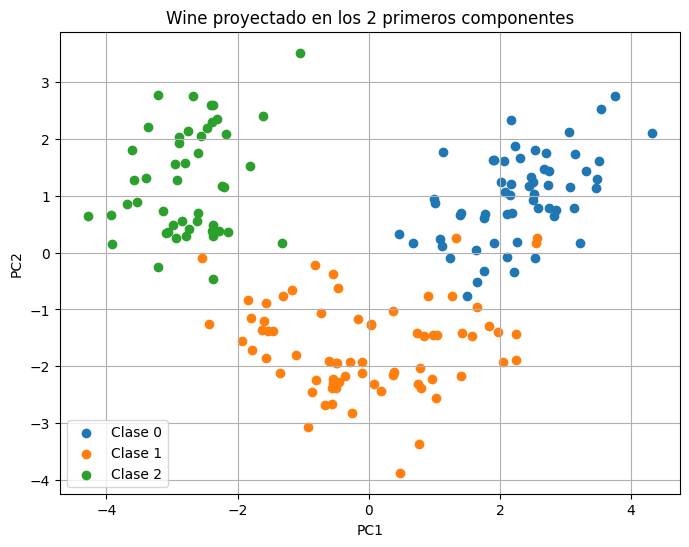

In [6]:
plt.figure(figsize=(8,6))

for label, color in zip([0,1,2], ['red','green','blue']):
    subset = X_pca[y == label]
    plt.scatter(subset[:,0], subset[:,1], label=f"Clase {label}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine proyectado en los 2 primeros componentes")
plt.legend()
plt.grid()
plt.show()

### 3.3.8. Interpretación del gráfico

Preguntas clave:

<div style="background-color:green;color:white">

<br>

* ¿Se observan grupos diferenciados?
* ¿Hay separación clara entre clases?
* ¿Qué indica esto sobre las variables originales?

<br>



---

Aquí se ve claramente que PCA:

* Ha reducido dimensionalidad.
* Mantiene estructura.
* Permite visualización clara.

Esto conecta directamente con la teoría de preservación de varianza.

### 3.3.9. Selección del número óptimo de componentes

En PCA no fijamos el número de componentes de forma arbitraria.
Una práctica habitual es analizar la varianza acumulada y elegir el número mínimo de componentes que conserve un alto porcentaje de la información (por ejemplo, 95 %).

Primero entrenamos PCA utilizando todos los componentes posibles:


In [7]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)


### 3.3.9.1. Método del codo



Mostramos una gráfica con la varianza individual

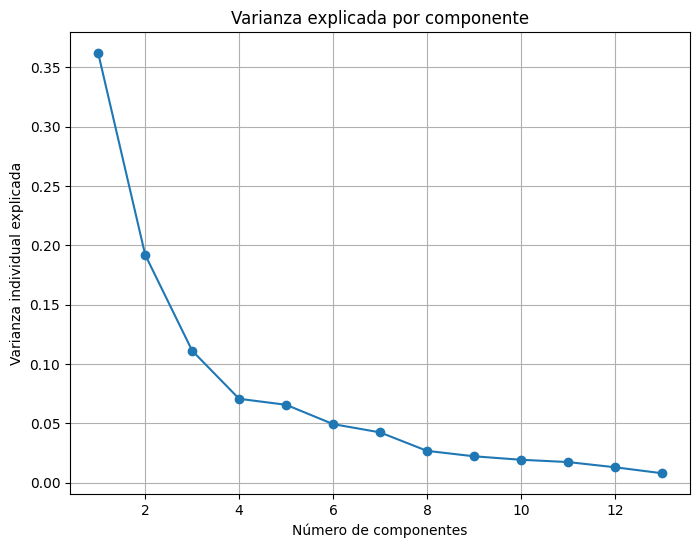

In [8]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(varianza)+1), varianza, marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza individual explicada")
plt.title("Varianza explicada por componente")
plt.grid()
plt.show()


En el gráfico no se ve claro, pero se puede inteuir que el codo está a partir del cuarto componente.

### 3.3.9.2. Componentes para un porcentaje

Vamos a buscar un portentaje de 90%, para tomar una decisión objetiva, utilizamos la varianza acumulada:

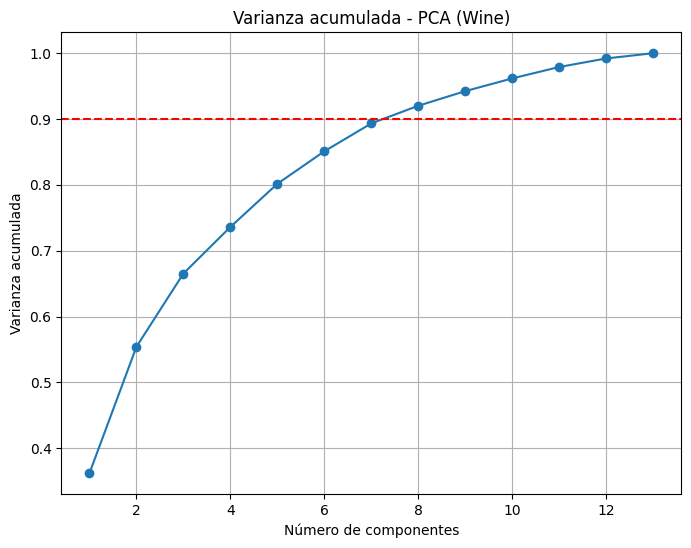

In [9]:
varianza_acumulada = np.cumsum(varianza)

plt.figure(figsize=(8,6))
plt.plot(range(1, len(varianza_acumulada)+1),
         varianza_acumulada,
         marker='o')

plt.axhline(y=0.90, color='r', linestyle='--')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada - PCA (Wine)")
plt.grid()
plt.show()


La línea roja marca el umbral del 90 %.

Calculamos automáticamente el número mínimo de componentes necesarios:

In [10]:
d = np.argmax(varianza_acumulada >= 0.90) + 1
d

np.int64(8)

Significa que necesitamos 8 componentes para conservar al menos el 90 % de la información original.

Ahora aplicamos para reducir de 13 a 8.


In [11]:
pca_95 = PCA(n_components=0.90)
X_reduced = pca_95.fit_transform(X_scaled)

X_reduced.shape

(178, 8)

### 3.3.10.  Comparación con modelo supervisado


In [12]:
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

# -------------------------
# SIN PCA
# -------------------------
start = time.time()

model = RandomForestClassifier()
model.fit(X_train, y_train)

end = time.time()
tiempo_original = end - start

acc_original = accuracy_score(y_test, model.predict(X_test))


# -------------------------
# CON PCA
# -------------------------
pca = PCA(n_components=0.95)

start = time.time()

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = RandomForestClassifier()
model_pca.fit(X_train_pca, y_train)

end = time.time()
tiempo_pca = end - start

acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))


# -------------------------
# Cálculo de diferencias porcentuales
# -------------------------

dif_accuracy = acc_pca - acc_original
dif_tiempo = tiempo_original - tiempo_pca

porcentaje_tiempo = (dif_tiempo / tiempo_original) * 100 if tiempo_original != 0 else 0
porcentaje_accuracy = (dif_accuracy / acc_original) * 100 if acc_original != 0 else 0


# -------------------------
# RESULTADOS
# -------------------------
print("=== Comparación Random Forest ===\n")

print(f"Dimensiones originales: {X_train.shape[1]}")
print(f"Dimensiones tras PCA: {X_train_pca.shape[1]}\n")

print(f"Accuracy sin PCA: {acc_original:.4f}")
print(f"Accuracy con PCA: {acc_pca:.4f}")
print(f"Diferencia de accuracy: {porcentaje_accuracy:.2f} %\n")

print(f"Tiempo sin PCA: {tiempo_original:.6f} segundos")
print(f"Tiempo con PCA: {tiempo_pca:.6f} segundos")
print(f"Reducción de tiempo: {porcentaje_tiempo:.2f} %")

=== Comparación Random Forest ===

Dimensiones originales: 13
Dimensiones tras PCA: 10

Accuracy sin PCA: 0.9815
Accuracy con PCA: 0.9815
Diferencia de accuracy: 0.00 %

Tiempo sin PCA: 0.119870 segundos
Tiempo con PCA: 0.115235 segundos
Reducción de tiempo: 3.87 %


### 3.3.11.  Reflexión final

<div style="background-color:green;color:white">

<br>

Preguntas clave:

* ¿Reduce dimensionalidad?
* ¿Cuánta información conserva?
* ¿Mejora o empeora la precisión?
* ¿Cuándo usarías PCA en un proyecto real?

<br>

## PCA para compresión de imágenes

En una imagen digital, cada píxel es una variable.

Por ejemplo:

* Una imagen de 28 × 28 píxeles tiene
  28 × 28 = **784 variables**.

Esto significa que cada imagen puede interpretarse como un punto en un espacio de 784 dimensiones.

En problemas reales de visión artificial:

* Las imágenes pueden tener miles o millones de píxeles.
* El entrenamiento de modelos puede volverse muy costoso.
* Muchas zonas de la imagen contienen información redundante.

PCA se utiliza en imágenes principalmente para:

1. **Reducir dimensionalidad**

   * Pasar de cientos o miles de píxeles a un número menor de componentes.
   * Simplificar el problema.

2. **Compresión**

   * Guardar menos información manteniendo la estructura principal.
   * Reducir espacio de almacenamiento.

3. **Eliminar ruido**

   * Las componentes principales conservan la información más importante.
   * Las componentes pequeñas suelen representar ruido.

4. **Acelerar entrenamiento**

   * Menos dimensiones → menos cálculos.
   * Modelos más rápidos.

### Ejemplo paso a paso con Olivetti Faces

Ahora aplicaremos PCA al dataset Olivetti Faces, que contiene imágenes de rostros en escala de grises.

Cada imagen:

* Tamaño: 64 x 64
* Dimensiones originales: 4096


#### Paso 1: Cargar Olivetti Faces


In [13]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)
X, y = olivetti.data, olivetti.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


---

#### Paso 2: Aplicar PCA conservando el 95 % de varianza

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

print("Dimensiones originales:", X_train.shape[1])
print("Dimensiones tras PCA:", X_train_reduced.shape[1])

Dimensiones originales: 4096
Dimensiones tras PCA: 104


Aquí veremos que:

* Se pasa de 4096 dimensiones a un número mucho menor.
* Se conserva el 95 % de la información.


---

#### Paso 3: Reconstruir imágenes

In [15]:
X_test_recovered = pca.inverse_transform(X_test_reduced)


---

#### Paso 4: Visualizar comparación

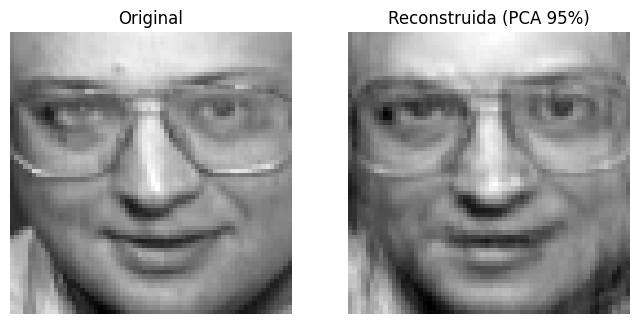

In [16]:
idx = 0

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_test[idx].reshape(64,64), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_test_recovered[idx].reshape(64,64), cmap='gray')
plt.title("Reconstruida (PCA 95%)")
plt.axis("off")

plt.show()


#### Interpretación

* La imagen reconstruida se parece mucho a la original.
* Puede verse ligeramente más borrosa.
* Esa diferencia es la información perdida al reducir dimensionalidad.

---

#### Error de reconstrucción

In [17]:
error = np.mean((X_test - X_test_recovered) ** 2)
error

np.float32(0.0025106287)

Cuanto menor sea el error:

* Mejor hemos conservado la información.
* Más fiel es la reconstrucción.

In [18]:
X_reduced = pca.fit_transform(X_train)

## PCA incremental

Un problema del PCA clásico es que necesita cargar todo el conjunto de datos en memoria para calcular los componentes principales.

Cuando el dataset es pequeño (como Wine o Titanic), esto no supone ningún inconveniente. Sin embargo, en problemas reales de Big Data, donde pueden existir millones de muestras, el conjunto completo puede no caber en memoria.

Para resolver este problema existen algoritmos de **PCA incremental**.

La idea es sencilla:

* En lugar de procesar todo el dataset a la vez,
* Se divide en pequeños bloques (mini-lotes),
* Y se procesan uno a uno.

De esta forma, el modelo va actualizando los componentes principales progresivamente sin necesidad de cargar todos los datos simultáneamente.

---

### ¿Cuándo es útil?

El PCA incremental es útil cuando:

* El dataset es muy grande.
* La memoria disponible es limitada.
* Los datos llegan en flujo continuo (streaming).

Es importante destacar que:

> PCA incremental no es necesariamente más rápido que el PCA clásico.
> Su principal ventaja es el menor consumo de memoria.


###  PCA incremental aplicado a Olivetti Faces

En el ejemplo anterior utilizamos PCA clásico para reducir las 4096 dimensiones de Olivetti Faces.

Sin embargo, si el dataset fuera mucho mayor (millones de imágenes), podría no caber completamente en memoria. En ese caso, usaríamos PCA incremental, que procesa los datos por bloques.


#### Paso 1: Importar IncrementalPCA

In [19]:
from sklearn.decomposition import IncrementalPCA
import numpy as np


#### Paso 2: Definir el modelo

Reduciremos dimensionalidad conservando, por ejemplo, 100 componentes:

In [20]:
ipca = IncrementalPCA(n_components=100)


Aquí estamos indicando:

- No queremos conservar un porcentaje,

- Queremos exactamente 100 componentes principales

In [21]:
batch_size = 1000

for i in range(0, X_train.shape[0], batch_size):
    X_batch = X_train[i:i+batch_size]
    ipca.partial_fit(X_batch)


Aquí:

* No cargamos todo el dataset en el algoritmo de una sola vez.

* Se actualizan los componentes progresivamente.

#### Paso 4: Transformar los datos

Una vez entrenado el modelo:

In [22]:
X_train_reduced = ipca.transform(X_train)
X_test_reduced = ipca.transform(X_test)

X_train_reduced.shape


(280, 100)

### Diferencia clave con PCA clásico

| PCA clásico                  | PCA incremental             |
| ---------------------------- | --------------------------- |
| Usa todo el dataset a la vez | Procesa por bloques         |
| Más simple                   | Más escalable               |
| Ideal para datasets pequeños | Ideal para datasets grandes |

# Ejercicios

<div style="background-color:green;color:white">

<br>

## 1. Fundamentos conceptuales

1. Explica al menos **tres motivaciones** para reducir la dimensionalidad de un dataset.
2. ¿Qué es la “maldición de la dimensionalidad”?
3. ¿Cuáles son los principales inconvenientes de reducir dimensionalidad?

<br>

<div style="background-color:green;color:white">

## 2. PCA aplicado a Olivetti Faces

### 2.1 Preparación

* Carga el dataset Olivetti Faces.
* Divide en conjunto de entrenamiento y prueba.
* Indica cuántas dimensiones tiene cada imagen.

<br>


<div style="background-color:green;color:white">

### 2.2 Clasificador sin PCA

1. Entrena un clasificador Random Forest.
2. Mide el tiempo de entrenamiento.
3. Calcula la accuracy en test.
4. Anota los resultados.

<br>

---

<div style="background-color:green;color:white">

### 2.3 Reducción con PCA

1. Aplica PCA conservando el 95 % de la varianza.
2. Indica cuántas dimensiones se han conservado.
3. Explica qué significa conservar el 95 %.


<br>

---

<div style="background-color:green;color:white">

### 2.4 Clasificador con PCA

1. Entrena el mismo clasificador con los datos reducidos.
2. Mide el tiempo de entrenamiento.
3. Calcula la accuracy en test.
4. Compara con el modelo sin PCA.

<br>

---

<div style="background-color:green;color:white">

<br>

Responde razonadamente:

* ¿Ha mejorado el tiempo de entrenamiento?
* ¿Ha mejorado la precisión?
* ¿Compensa aplicar PCA en este caso?
* ¿En qué tipo de problema sí sería especialmente útil?

<br>

<div style="background-color:green;color:white">

## 3. PCA aplicado al dataset Breast Cancer

Utilizaremos el dataset *load_breast_cancer* de scikit-learn.

---

### 3.1 Exploración inicial

1. Carga el dataset.
2. ¿Cuántas muestras tiene?
3. ¿Cuántas variables?
4. ¿Hay valores nulos?
5. Analiza la matriz de correlación.
6. ¿Crees que PCA puede ser útil aquí? Justifica.

<br>

In [23]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.shape

(569, 30)

<div style="background-color:green;color:white">

### 3.2 Análisis de varianza

1. Escala los datos.
2. Aplica PCA completo.
3. Representa la varianza explicada individual.
4. Representa la varianza acumulada.
5. ¿Se observa un “codo”?
6. ¿Cuántos componentes son necesarios para conservar el 95 %?
7. Justifica tu elección.

<br>

---

<div style="background-color:green;color:white">

### 3.3 Visualización

1. Reduce a 2 componentes.
2. Representa PC1 vs PC2.
3. Colorea por clase (maligno / benigno).
4. ¿Se observan grupos diferenciados?
5. ¿PCA ayuda a visualizar mejor la estructura del dataset?

<br>

<div style="background-color:green;color:white">

### 3.4 Impacto en clasificación

1. Divide en train/test.
2. Entrena un clasificador (Random Forest o Logistic Regression) con las 30 variables originales.
3. Calcula accuracy y tiempo de entrenamiento.
4. Reduce dimensionalidad conservando el 95 %.
5. Entrena el mismo modelo con los datos reducidos.
6. Compara resultados.

<br>

<div style="background-color:green;color:white">

<br>

Preguntas obligatorias:

* ¿Mejora la precisión?
* ¿Se reduce el tiempo?
* ¿Compensa aplicar PCA?
* ¿Qué ocurre si reduces demasiado el número de componentes?

<br>

<div style="background-color:green;color:white">

<br>

1. ¿En qué tipo de dataset es especialmente útil PCA?
2. ¿En qué casos puede empeorar el rendimiento?
3. Diferencia entre:

   * PCA clásico
   * PCA aleatorio
   * PCA incremental
4. ¿PCA es un algoritmo supervisado o no supervisado? Justifica.

<br>